# FESTO servo valve — supply characteristic

Supply pressure mapping: upstream = `supply_pressure` (AI ch6), downstream = `pam_valve_pressure` (AI ch1).

In [22]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'sweep_common.py').exists():
    ANALYSIS_DIR = Path('valve_sweep/analysis')
sys.path.insert(0, str(ANALYSIS_DIR.resolve()))

from sweep_common import (
    add_effective_area, load_config, load_sweep_bag, summarize_steps,
)

In [23]:
# Point this to a rosbag directory or directly to its .mcap file.
BAG_PATH = Path('~/koni_log/sweep_high_20260717_150745').expanduser()
CONFIG_PATH = ANALYSIS_DIR / 'calibration.yaml'

config = load_config(CONFIG_PATH)
samples = load_sweep_bag(BAG_PATH, config)
summary = summarize_steps(samples, config['analysis']['tail_duration_s'])
result = add_effective_area(summary, 'supply', config)
print(f'{len(samples):,} AI samples, {len(result)} voltage steps')

5,030 AI samples, 19 voltage steps


In [24]:
columns = [
    'step_index', 'command_voltage_v', 'sample_count',
    'flow_l_min_anr', 'flow_std_l_min',
    'upstream_pressure_kpa_g', 'downstream_pressure_kpa_g',
    'pressure_ratio', 'flow_factor_phi', 'mass_flow_kg_s',
    'effective_area_mm2', 'flow_direction_ok',
    'valid_pressure_ratio', 'flow_near_full_scale',
]
result[columns].round(6)

,step_index,command_voltage_v,sample_count,flow_l_min_anr,flow_std_l_min,upstream_pressure_kpa_g,downstream_pressure_kpa_g,pressure_ratio,flow_factor_phi,mass_flow_kg_s,effective_area_mm2,flow_direction_ok,valid_pressure_ratio,flow_near_full_scale
0,0,4.8,51,3.942065,0.328910,337.933757,0.155598,0.231027,1.0000,0.000079,0.076300,True,True,False
1,1,4.9,51,3.775706,0.304838,337.761721,0.122686,0.231042,1.0000,0.000076,0.073109,True,True,False
2,2,5.0,50,4.095223,0.240885,337.881938,0.141415,0.231022,1.0000,0.000082,0.079274,True,True,False
3,3,5.1,50,4.299691,0.309187,337.886515,0.297057,0.231374,1.0000,0.000086,0.083231,True,True,False
4,4,5.2,50,4.518808,0.422180,338.004009,0.173459,0.231031,1.0000,0.000091,0.087449,True,True,False
5,5,5.3,51,4.807937,0.245002,337.532835,0.209452,0.231361,1.0000,0.000096,0.093144,True,True,False
6,6,5.4,51,5.046095,0.253887,336.880573,0.230396,0.231753,1.0000,0.000101,0.097904,True,True,False
7,7,5.5,51,5.297419,0.228024,336.210366,0.255827,0.232166,1.0000,0.000106,0.102937,True,True,False
8,8,5.6,50,5.742586,0.194471,335.741072,0.280273,0.232471,1.0000,0.000115,0.111707,True,True,False
9,9,5.7,51,6.028662,0.280453,335.754085,0.356057,0.232638,1.0000,0.000121,0.117269,True,True,False


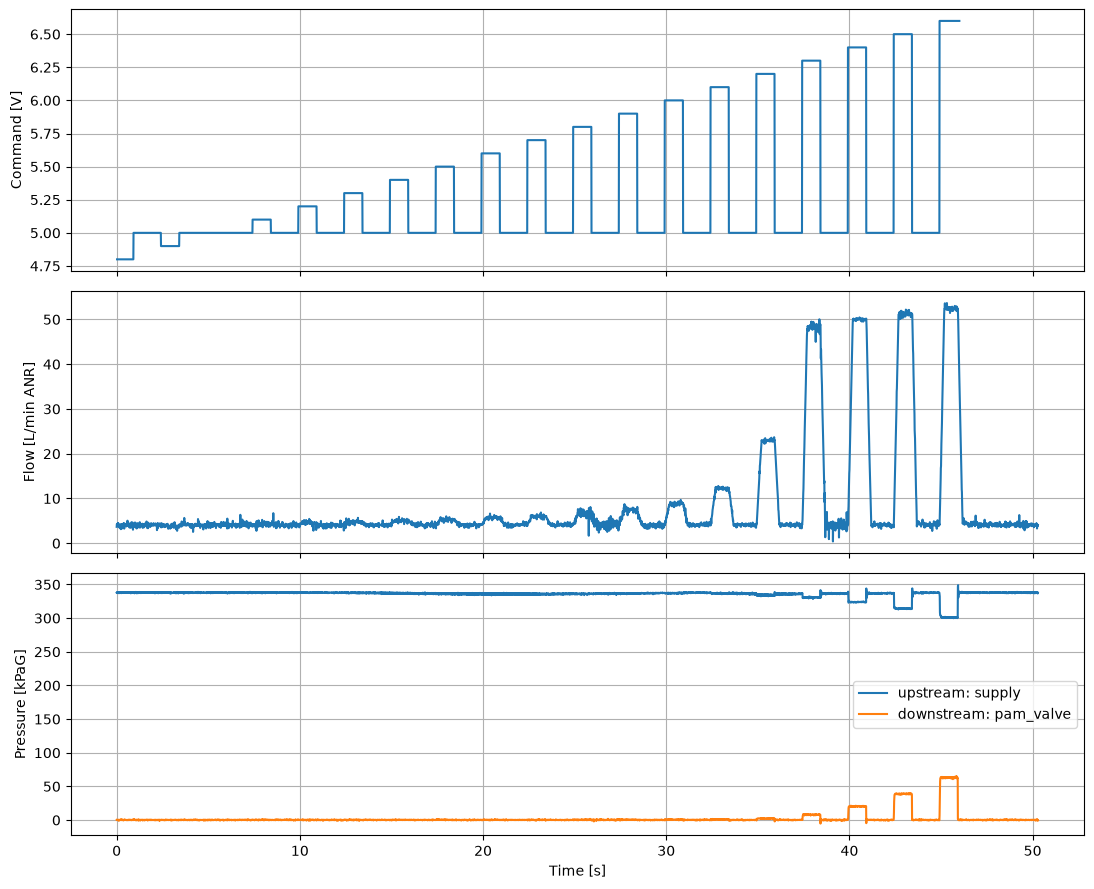

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(samples['time_s'], samples['command_voltage_v'])
axes[0].set_ylabel('Command [V]')
axes[1].plot(samples['time_s'], samples['flow_l_min_anr'])
axes[1].set_ylabel('Flow [L/min ANR]')
axes[2].plot(samples['time_s'], samples['supply_pressure_kpa_g'], label='upstream: supply')
axes[2].plot(samples['time_s'], samples['pam_valve_pressure_kpa_g'], label='downstream: pam_valve')
axes[2].set_ylabel('Pressure [kPaG]')
axes[2].set_xlabel('Time [s]')
axes[2].legend()
for axis in axes:
    axis.grid(True)
fig.tight_layout()

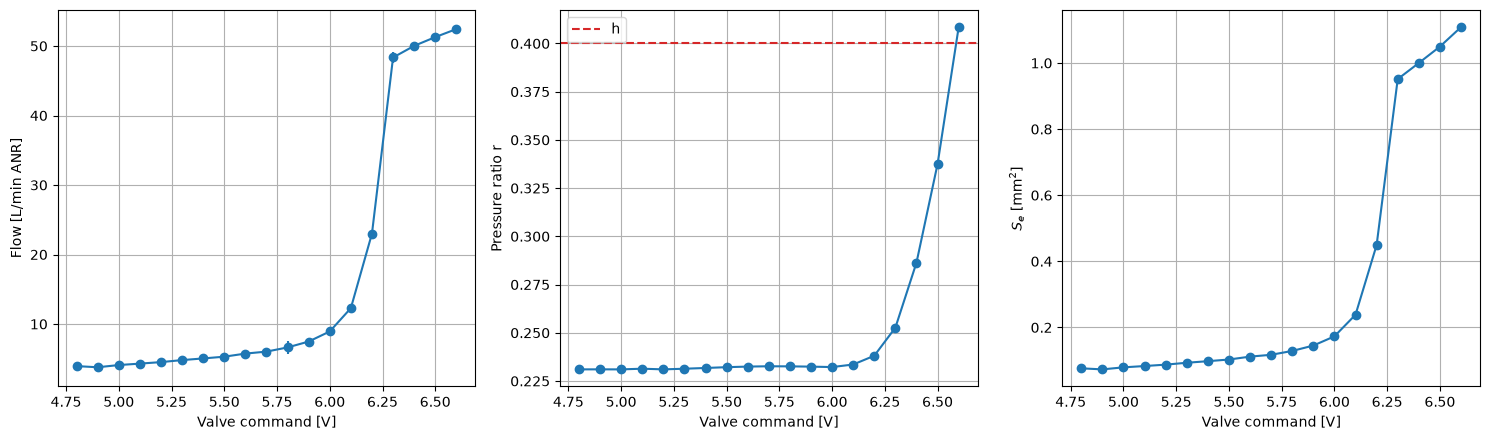

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].errorbar(result['command_voltage_v'], result['flow_l_min_anr'], yerr=result['flow_std_l_min'], marker='o')
axes[0].set_ylabel('Flow [L/min ANR]')
axes[1].plot(result['command_voltage_v'], result['pressure_ratio'], marker='o')
axes[1].axhline(config['model']['critical_pressure_ratio'], color='tab:red', linestyle='--', label='h')
axes[1].set_ylabel('Pressure ratio r')
axes[1].legend()
axes[2].plot(result['command_voltage_v'], result['effective_area_mm2'], marker='o')
axes[2].set_ylabel(r'$S_e$ [mm$^2$]')
for axis in axes:
    axis.set_xlabel('Valve command [V]')
    axis.grid(True)
fig.tight_layout()

In [27]:
problems = result.loc[
    (~result['flow_direction_ok'])
    | (~result['valid_pressure_ratio'])
    | result['flow_near_full_scale']
]
if problems.empty:
    print('No direction, pressure-ratio, or flow-range warnings.')
else:
    display(problems[columns])

No direction, pressure-ratio, or flow-range warnings.


In [28]:
# Optional CSV export
# output_path = BAG_PATH.with_name(BAG_PATH.name + '_supply_analysis.csv')
# result.to_csv(output_path, index=False)
# output_path